## LiDAR Measurements

A LiDAR gives us only the range and the two angles of spherical coodinates of the object. A simple LiDAR model can shown as following:
$$ Z_k = [r_k, {\theta}_k, {\phi}_k] $$

In [1]:
import numpy as np
import math
from scipy.constants import speed_of_light as c
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d.axes3d as axes3d

In [2]:
def Cartesian_positions(X):
    """
    Convert shperical target state to LiDAR cartesian measurement.

    State:
        X = [x, y, z, vx, vy, vz]

    Measurement:
        z = [range, azimuth, elevation]
    """
    r = X[0]  # Range
    theta = X[1]   
    phi = X[2] 

    # Cartesian Coords
    x = r*math.sin(theta)*math.cos(phi)
    y = r*math.sin(theta)*math.sin(phi)
    z = r*math.cos(theta)

    return np.array([x, y, z], dtype=float)


### Applying the Extended Kalman Filter to model the 3D LiDAR


* LiDAR measurements

$$   Z = \text{[range, elevation, azimuth]} $$

* Final Information
$$
\text{Position= (x, y, z)}\newline
$$
$$
\text{Velocity} = (v_x, v_y, v_z) 
$$
$$
\text{speed}  = \sqrt{{v_x}^2 + {v_y}^2 + {v_z}^2} 
$$
$$
\text{Direction} = ({\theta}_v, {\phi}_v)
$$



In [3]:
class LiDAREKF:
    """
    3D LiDAR Extended Kalman Filter.

    State:
        x = [px, py, pz, vx, vy, vz]

    Measurement:
        z = [range, elevation, azimuth]
    """

    def __init__(self, dt, sigma_a, R):

        self.dt = dt
        self.sigma_a = sigma_a
        self.R = R

        # Initial state
        self.x = np.zeros(6)

        # Initial covariance
        self.P = np.eye(6)

        # State transition matrix
        self.F = self._create_F()

        # Process noise covariance
        self.Q = self._create_Q()

    # --------------------------------------------------
    # State transition matrix
    # --------------------------------------------------

    def _create_F(self):

        dt = self.dt

        F = np.array([
            [1, 0, 0, dt, 0,  0],
            [0, 1, 0, 0,  dt, 0],
            [0, 0, 1, 0,  0, dt],
            [0, 0, 0, 1,  0, 0],
            [0, 0, 0, 0,  1, 0],
            [0, 0, 0, 0,  0, 1]
        ], dtype=float)

        return F

    # --------------------------------------------------
    # Process noise covariance
    # --------------------------------------------------

    def _create_Q(self):

        dt = self.dt
        q = self.sigma_a**2

        Q = q * np.array([
            [dt**4 / 4, 0,          0,
             dt**3 / 2, 0,          0],

            [0,         dt**4 / 4,  0,
             0,         dt**3 / 2,  0],

            [0,         0,          dt**4 / 4,
             0,         0,          dt**3 / 2],

            [dt**3 / 2, 0,          0,
             dt**2,     0,          0],

            [0,         dt**3 / 2,  0,
             0,         dt**2,      0],

            [0,         0,          dt**3 / 2,
             0,         0,          dt**2]
        ])

        return Q

    # --------------------------------------------------
    # LiDAR measurement model
    # --------------------------------------------------

    @staticmethod
    def measurement_function(x):

        x, y, z = x[:3]

        rho = np.sqrt(x**2 + y**2)

        r = np.sqrt(x**2 + y**2 + z**2)

        theta = np.arctan2(y, x)

        phi = np.arctan2(z, rho)

        return np.array([
            r,
            theta,
            phi
        ])

    # --------------------------------------------------
    # Measurement Jacobian
    # --------------------------------------------------

    @staticmethod
    def measurement_jacobian(x):

        x, y, z = x[:3]   # Position

        rho2 = x**2 + y**2

        rho = np.sqrt(rho2)

        r2 = x**2 + y**2 + z**2

        r = np.sqrt(r2)

        # Avoid division by zero
        eps = 1e-12

        rho2 = max(rho2, eps)
        rho = max(rho, eps)
        r2 = max(r2, eps)
        r = max(r, eps)

        H = np.array([

            [
                x / r,
                y / r,
                z / r,
                0,
                0,
                0
            ],

            [
                -y / rho2,
                x / rho2,
                0,
                0,
                0,
                0
            ],

            [
                -x * z / (r2 * rho),
                -y * z / (r2 * rho),
                rho / r2,
                0,
                0,
                0
            ]

        ], dtype=float)

        return H

    # --------------------------------------------------
    # Normalize angle to [-pi, pi]
    # --------------------------------------------------

    @staticmethod
    def normalize_angle(angle):

        return (angle + np.pi) % (2 * np.pi) - np.pi

    # --------------------------------------------------
    # Prediction step
    # --------------------------------------------------

    def predict(self, dt=None):

        if dt is not None:
            if dt <= 0:
                raise ValueError("dt must be positive.")
            self.dt = float(dt)
            self.F = self._create_F()
            self.Q = self._create_Q()
        # State prediction
        self.x = self.F @ self.x

        # Covariance prediction
        self.P = (
            self.F @ self.P @ self.F.T
            + self.Q
        )

        return self.x.copy(), self.P.copy()

    # --------------------------------------------------
    # Measurement update
    # --------------------------------------------------

    def update(self, z):

        # Predicted measurement
        z_pred = self.measurement_function(self.x)

        # Measurement Jacobian
        H = self.measurement_jacobian(self.x)

        # Innovation
        y = z - z_pred

        # Normalize angular residuals
        y[1] = self.normalize_angle(y[1])
        y[2] = self.normalize_angle(y[2])

        # Innovation covariance
        S = (
            H @ self.P @ H.T
            + self.R
        )

        # Kalman gain
        K = (
            self.P @ H.T
            @ np.linalg.inv(S)
        )

        # State update
        self.x = self.x + K @ y

        # Joseph-form covariance update
        I = np.eye(6)

        IKH = I - K @ H

        self.P = (
            IKH @ self.P @ IKH.T
            + K @ self.R @ K.T
        )

        return self.x.copy(), self.P.copy()

#### Initializing the LiDAR

Suppose the LiDAR has:
* range standard deviation = 5 cm
* azimuth standard deviation = ${0.1}^o$
* elevation standard deviation = ${0.1}^o$

Note: These values can vary depending on the situation

In [4]:
sigma_r = 0.05
sigma_theta = np.deg2rad(0.1)
sigma_phi = np.deg2rad(0.1)

R = np.diag([
    sigma_r**2,
    sigma_theta**2,
    sigma_phi**2
])

### Create the EKF

In [5]:
dt = 0.1  # 10 Hz LiDAR
sigma_a = 1.0  # Assumed accelaration uncertainty

ekf = LiDAREKF(dt=dt, sigma_a=sigma_a, R=R)

#### Initialize the target

Suppose the first LiDAR measurement is:

$$ r = 11.36 m
\\ \theta = 26.565^{o}
\\ \phi = 10.025^{o}
$$

In [6]:
###### For example LiDAR produce some measurements ######

rng = np.random.default_rng(seed=42)

# 50 timestamps: 0.0, 0.1, ..., 4.9 seconds
timestamps = np.arange(50, dtype=float) * 0.1

# Continue the trend in your original measurements
ideal_measurements = np.column_stack([
    11.36 + 5.10 * timestamps,   # Range (m)
    0.464 + 0.18 * timestamps,   # Azimuth (rad)
    0.175 + 0.05 * timestamps,   # Elevation (rad)
])

# Measurement-noise standard deviations: m, rad, rad
noise_std = np.array([0.05, 0.002, 0.002])

measurements = ideal_measurements + rng.normal(
    loc=0.0,
    scale=noise_std,
    size=ideal_measurements.shape
)

initial_position = Cartesian_positions(measurements[0])

ekf.x = np.array([
    initial_position[0],
    initial_position[1],
    initial_position[2],
    0.0,
    0.0,
    0.0
])

ekf.P = np.diag([
    0.1**2,
    0.1**2,
    0.1**2,
    5.0**2,
    5.0**2,
    5.0**2
])


### Position, Velocity, Speed, and Direction after every update

* position:
$$

X = (x, y, z)

$$

* Velocity:

$$

\text{velocity} = (v_x, v_y, v_z)

$$

* Speed:
$$

v = \sqrt({{v_x}^2 + {v_y}^2 + {v_z}^2})

$$

* Direction:
$$
\text{direction} = ({\theta}_v, {\phi}_v)
$$

In [7]:
# Storage
positions = []
velocities = []
speeds = []
directions = []

# If measurements are separated by a fixed time interval
time = np.arange(len(measurements)) * ekf.dt

for z in measurements:
    
    z = np.asarray(z)
    # 1. Predict
    x_pred, P_pred = ekf.predict()

    # 2. Correct using LiDAR
    x_est, P_est = ekf.update(z)

    vx, vy, vz = ekf.x[3:6]      # Velocity components after update

    # Position
    position = ekf.x[:3].copy()

    speed = np.linalg.norm(ekf.x[3:6])  # Speed of the object

    # Direction angles are calculated in degrees
    vel_hor = np.sqrt(vx**2 + vy**2)
    theta = np.rad2deg(np.arctan2(vz, vel_hor))
    
    phi = np.rad2deg(np.arctan2(vy, vx))


    positions.append(position)
    velocities.append([vx, vy, vz])
    speeds.append(speed)
    directions.append([theta, phi])

    # print(f"Position: ", ekf.x[:3])
    # print(f'Velocity: ', ekf.x[3:6])
    # print(f'Speed: {speed: .3f}')
    # print(f'Direction: ({theta: .3f}, {phi: .3f})\n')   
    
# Convert to NumPy arrays
positions = np.array(positions)
velocities = np.array(velocities)
speeds = np.array(speeds)   
directions = np.array(directions)

#### Motion of the Target

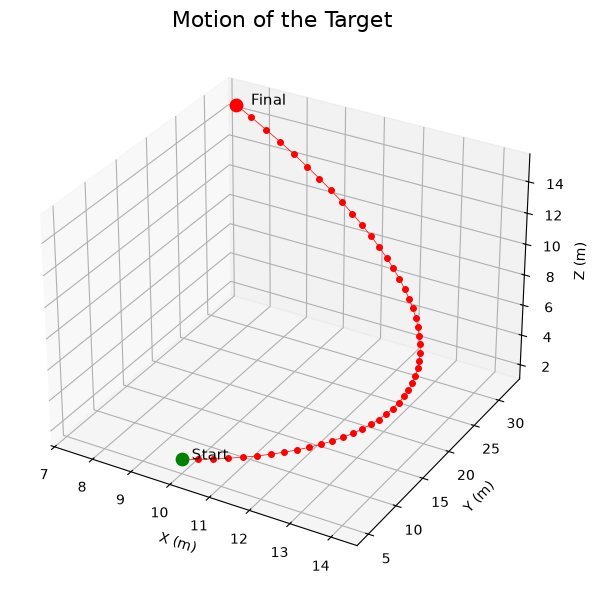

In [ ]:
r = ideal_measurements[:, 0]
azimuth = ideal_measurements[:, 1]
elevation = ideal_measurements[:, 2]

# Convert spherical coordinates to Cartesian coordinates
x = r * np.cos(elevation) * np.cos(azimuth)
y = r * np.cos(elevation) * np.sin(azimuth)
z = r * np.sin(elevation)

# Plot 3D motion of the target
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    x, y, z,
    color="Red",
    marker="o",
    markersize=4,
    linewidth=0.5
)

# Starting position
ax.scatter(
    x[0], y[0], z[0],
    color="green",
    s=80,
    zorder=5
)

ax.text(
    x[0], y[0], z[0],
    "  Start",
    fontsize=11
)

# Final position
ax.scatter(
    x[-1], y[-1], z[-1],
    color="red",
    s=80,
    zorder=5
)

ax.text(
    x[-1], y[-1], z[-1],
    "   End",
    fontsize=11
)

ax.set_title("Motion of the Target", fontsize=16)
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_zlabel("Z (m)")

ax.grid(True)
plt.tight_layout()
plt.show()


### Plotting the results

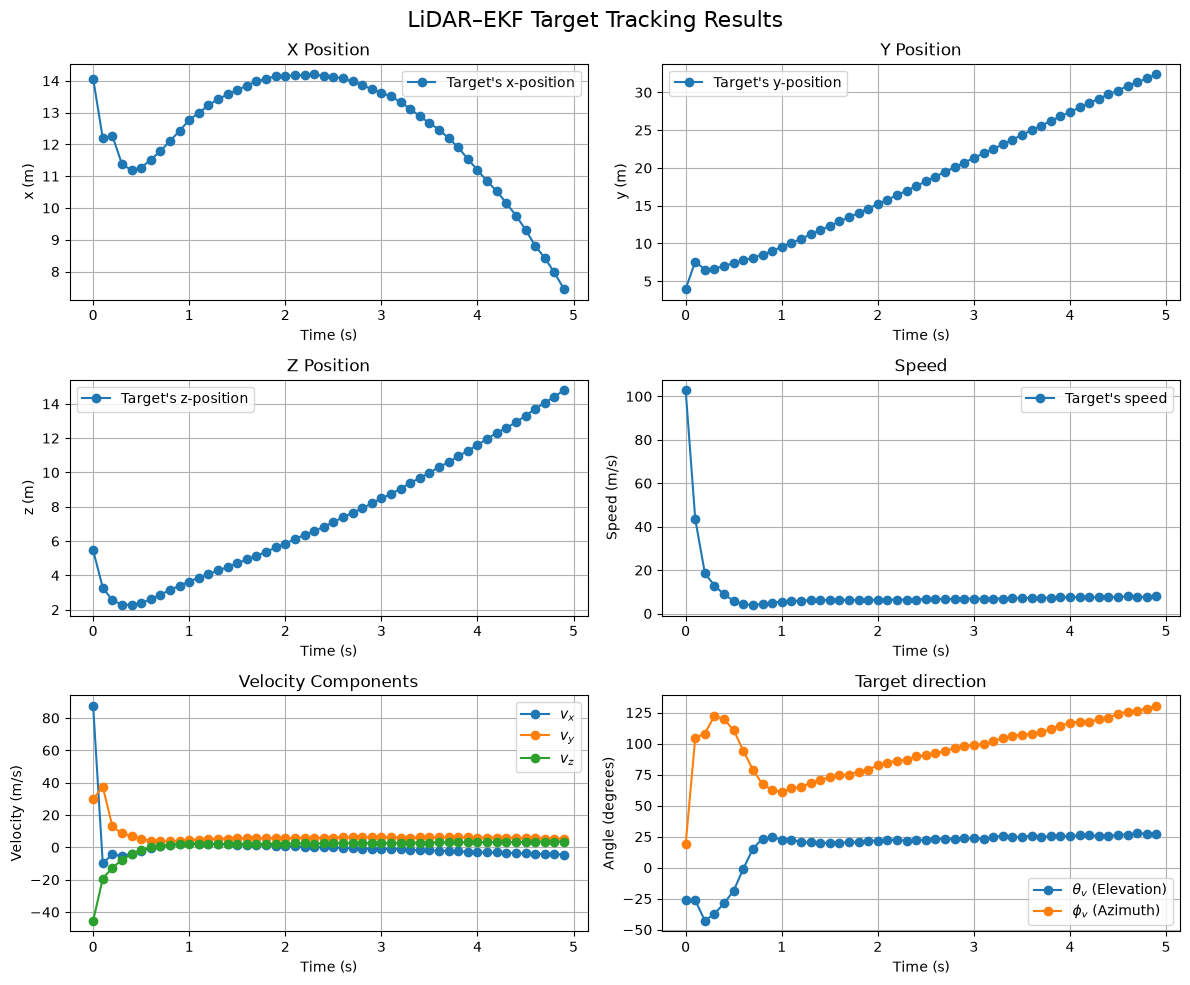

In [16]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

# --------------------------------------------------
# 1. X position
# --------------------------------------------------
axes[0, 0].plot(time, positions[:, 0], marker='o', label=r"Target's x-position")
axes[0, 0].set_title("X Position")
axes[0, 0].set_xlabel("Time (s)")
axes[0, 0].set_ylabel("x (m)")
axes[0, 0].legend()
axes[0, 0].grid(True)

# --------------------------------------------------
# 2. Y position
# --------------------------------------------------
axes[0, 1].plot(time, positions[:, 1], marker='o', label=r"Target's y-position")
axes[0, 1].set_title("Y Position")
axes[0, 1].set_xlabel("Time (s)")
axes[0, 1].set_ylabel("y (m)")
axes[0, 1].legend()
axes[0, 1].grid(True)

# --------------------------------------------------
# 3. Z position
# --------------------------------------------------
axes[1, 0].plot(time, positions[:, 2], marker='o', label=r"Target's z-position")
axes[1, 0].set_title("Z Position")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].set_ylabel("z (m)")
axes[1, 0].legend()
axes[1, 0].grid(True)

# --------------------------------------------------
# 4. Speed
# --------------------------------------------------
axes[1, 1].plot(time, speeds, marker='o', label=r"Target's speed")
axes[1, 1].set_title("Speed")
axes[1, 1].set_xlabel("Time (s)")
axes[1, 1].set_ylabel("Speed (m/s)")
axes[1, 1].legend()
axes[1, 1].grid(True)

# --------------------------------------------------
# 5. Velocity components
# --------------------------------------------------
axes[2, 0].plot(time, velocities[:, 0], marker='o', label='$v_x$')
axes[2, 0].plot(time, velocities[:, 1], marker='o', label='$v_y$')
axes[2, 0].plot(time, velocities[:, 2], marker='o', label='$v_z$')

axes[2, 0].set_title("Velocity Components")
axes[2, 0].set_xlabel("Time (s)")
axes[2, 0].set_ylabel("Velocity (m/s)")
axes[2, 0].legend()
axes[2, 0].grid(True)

# --------------------------------------------------
# 6. Velocity direction
# --------------------------------------------------
axes[2, 1].plot(
    time,
    directions[:, 0],
    marker='o',
    label=r'$\theta_v$ (Elevation)'
)

axes[2, 1].plot(
    time,
    directions[:, 1],
    marker='o',
    label=r'$\phi_v$ (Azimuth)'
)

axes[2, 1].set_title("Target direction")
axes[2, 1].set_xlabel("Time (s)")
axes[2, 1].set_ylabel("Angle (degrees)")
axes[2, 1].legend()
axes[2, 1].grid(True)

# --------------------------------------------------
# Overall figure
# --------------------------------------------------
fig.suptitle(
    "LiDAR–EKF Target Tracking Results",
    fontsize=16
)

plt.tight_layout()
plt.show()